# 🏥 MedGemma Differential Diagnosis System
### MultiCaRe Dataset + LangGraph

This notebook runs a structured, multi-stage diagnostic pipeline:
1. **Load Case** — patient data, imaging metadata, clinical notes
2. **Load Images** — base64 encode case images for multimodal analysis
3. **Initial Diagnosis** — MedGemma generates primary + differential diagnoses with confidence
4. **Bias Check** — identifies anchoring, availability, and other cognitive biases
5. **Alternative Hypotheses** — explores missed diagnoses and zebra conditions
6. **Final Report** — structured report with ground-truth comparison

## 1. Setup & Configuration

In [14]:
# Install dependencies
# !pip install langgraph langchain-core huggingface_hub transformers torch pillow accelerate

import os
import json
from IPython.display import display, Markdown, Image as IPImage
from pathlib import Path
import base64
from PIL import Image
import io

# ─── CONFIGURATION ─────────────────────────────────────────────────────────

# Path to your parsed MultiCaRe JSON file
os.environ['MULTICARE_DATASET_PATH'] = 'cxr_schema_dataset/dataset_per_case.json'

# Base path where images are stored
# JSON paths are like "images/filename.webp", so base path should be the parent folder
os.environ['MULTICARE_IMAGES_PATH'] = 'cxr_full_dataset'

# HuggingFace token — read from cached login, or set explicitly
_token_file = Path.home() / '.cache' / 'huggingface' / 'token'
if _token_file.exists():
    os.environ['HF_TOKEN'] = _token_file.read_text().strip()
    print(f'🔑 HF token loaded from cache ({os.environ["HF_TOKEN"][:8]}...)')
else:
    os.environ['HF_TOKEN'] = 'hf_your_token_here'
    print('⚠️  No cached token found. Set HF_TOKEN manually or run: huggingface-cli login')

# Model to use
os.environ['MEDGEMMA_MODEL'] = 'google/medgemma-1.5-4b-it'  # or google/medgemma-1.5-27b-it

# Set to '1' to use local GPU instead of HF Inference API
os.environ['USE_LOCAL_MEDGEMMA'] = '1'

print('✅ Configuration set')


🔑 HF token loaded from cache (hf_ityPh...)
✅ Configuration set


## 2. Browse Available Cases

In [15]:
dataset_path = Path(os.environ['MULTICARE_DATASET_PATH'])

with open(dataset_path) as f:
    dataset = json.load(f)

# Support list or dict
if isinstance(dataset, list):
    cases = {c['case_id']: c for c in dataset}
else:
    cases = dataset

print(f'📂 Total cases in dataset: {len(cases)}')
print()

# Show first 10 cases as a table
rows = []
for cid, c in list(cases.items())[:15]:
    patient = c.get('patient', {})
    assessment = c.get('assessment', {})
    prov = c.get('provenance', {})
    rows.append({
        'Case ID': cid[:12] + '...',
        'Age/Sex': f"{patient.get('age_years', '?')}/{patient.get('sex', '?')[0].upper()}",
        'Chief Complaint': c.get('presentation', {}).get('chief_complaint', 'N/A')[:40],
        'Primary Dx': assessment.get('diagnosis_primary', 'N/A'),
        'Images': len(c.get('images', [])),
        'Modality': c.get('study', {}).get('modality', 'N/A'),
    })

import pandas as pd
pd.set_option('display.max_colwidth', 50)
pd.DataFrame(rows)

📂 Total cases in dataset: 750



,Case ID,Age/Sex,Chief Complaint,Primary Dx,Images,Modality
0,e0a8f078-fb8...,65.0/M,Productive cough and chest pain,mucormycosis,4,CXR
1,5a336bad-577...,74.0/F,blisters on the skin and ulcers in the o,dermatitis herpetiformis,18,CXR
2,ba0d8c10-685...,53.0/F,abdominal pain and vomiting,port catheter embolization to pulmonary artery,1,CXR
3,247513aa-981...,0.0/M,"Dyspnea, cough, and sputum.",true thymic hyperplasia,4,CXR
4,d33d8d79-7fe...,48.0/F,Recurrent episodes of diffuse chest pain,sheehan syndrome,4,CXR
5,7784e783-369...,None/F,Recurrent syncope,pulmonary embolism,7,CXR
6,356f383d-391...,41.0/M,dyspnea,paragonimus kellicotti infection,4,CXR
7,fb5001b6-96f...,26.0/M,Fever and altered mental status.,tuberculous meningitis,3,CXR
8,b490fd15-9b6...,65.0/M,"dyspnea, fatigue, and bilateral pedal ed",idiopathic isolated right ventricular cardiomy...,7,CXR
9,36bf7e8e-39a...,15.0/M,Aggravated hemoptysis,anomalous origin of left pulmonary artery,4,CXR


## 3. Select a Case & Preview

In [16]:
# ─── SELECT YOUR CASE HERE ───────────────────────────────────────────────
CASE_ID = 'e0a8f078-fb8f-5281-ae67-256e060d0ef0'  # Change this to any case_id
# ────────────────────────────────────────────────────────────────────────

case = cases[CASE_ID]
patient = case['patient']
presentation = case['presentation']
prov = case['provenance']

display(Markdown(f"""
## 📋 Case Preview: `{CASE_ID[:16]}...`

**Source:** {prov.get('article_title', 'N/A')}

| Field | Value |
|---|---|
| Age | {patient.get('age_years', '?')} years |
| Sex | {patient.get('sex', '?')} |
| Immunocompromised | {patient.get('immunocompromised', '?')} |
| Chief Complaint | {presentation.get('chief_complaint', 'N/A')} |
| Duration | {presentation.get('symptom_duration', 'N/A')} |
| Comorbidities | {', '.join(patient.get('comorbidities', [])) or 'None'} |
| Images | {len(case.get('images', []))} |

**HPI:** {presentation.get('hpi', 'N/A')}

**Ground Truth Diagnosis:** `{case.get('assessment', {}).get('diagnosis_primary', 'N/A')}`
"""))


## 📋 Case Preview: `e0a8f078-fb8f-52...`

**Source:** A rare case of an immunocompetent patient with isolated pulmonary mucormycosis

| Field | Value |
|---|---|
| Age | 65.0 years |
| Sex | male |
| Immunocompromised | no |
| Chief Complaint | Productive cough and chest pain |
| Duration | Four weeks |
| Comorbidities | hypertension |
| Images | 4 |

**HPI:** A 65-year-old man presented with productive cough and chest pain for four weeks, aggravated by deep breathing. His symptoms also included fever, weight loss, and progressive myalgia. He was initially treated with antibiotics but returned with dyspnea and fever, eventually leading to a diagnosis of mucormycosis.

**Ground Truth Diagnosis:** `mucormycosis`


🖼️  4 images in this case:


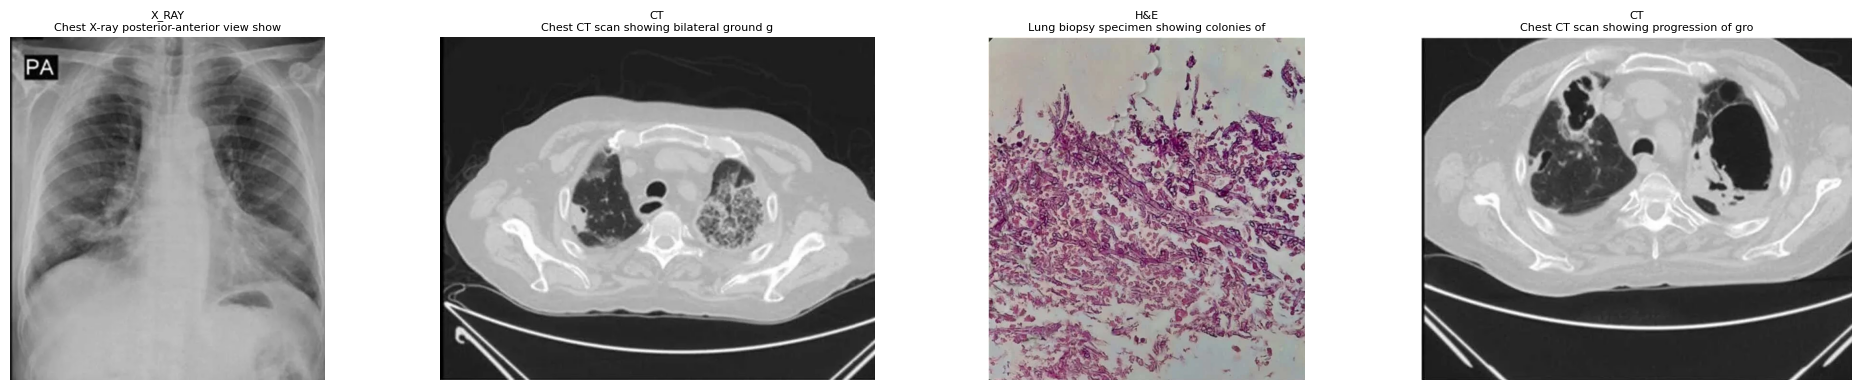

In [17]:
# Preview case images
base_path = Path(os.environ['MULTICARE_IMAGES_PATH'])
images = case.get('images', [])

print(f'🖼️  {len(images)} images in this case:')

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

n = len(images)
if n > 0:
    fig, axes = plt.subplots(1, min(n, 4), figsize=(5 * min(n, 4), 4))
    if n == 1:
        axes = [axes]
    
    for i, (img_meta, ax) in enumerate(zip(images[:4], axes)):
        img_path = base_path / img_meta['local_image_path']
        if img_path.exists():
            from PIL import Image as PILImage
            img = PILImage.open(img_path).convert('RGB')
            ax.imshow(img)
            ax.set_title(f"{img_meta.get('image_subtype', '?').upper()}\n{img_meta.get('caption', '')[:40]}", 
                        fontsize=8, wrap=True)
        else:
            ax.text(0.5, 0.5, f'Image not found:\n{img_meta["local_image_path"]}', 
                   ha='center', va='center', transform=ax.transAxes, color='red')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

## 4. Run the Full Diagnosis Pipeline

In [18]:
# Import the graph
import sys
sys.path.insert(0, '.')  # Ensure local module is importable

from diagnosis_graph import build_diagnosis_graph, DiagnosisState, preload_model

print('✅ Diagnosis graph imported')


✅ Diagnosis graph imported


In [19]:
# Pre-load the model into GPU memory so the pipeline doesn't stall on first call.
# Run this cell once — subsequent pipeline runs will reuse the cached weights.
from diagnosis_graph import preload_model
preload_model()


[preload] Model already loaded: google/medgemma-1.5-4b-it


In [20]:
# GPU status check — run before the pipeline to confirm GPU is active
import torch

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        name = torch.cuda.get_device_name(i)
        total = torch.cuda.get_device_properties(i).total_memory / 1024**3
        used  = torch.cuda.memory_allocated(i) / 1024**3
        reserved = torch.cuda.memory_reserved(i) / 1024**3
        print(f'GPU {i}: {name}')
        print(f'  Total VRAM : {total:.1f} GB')
        print(f'  Allocated  : {used:.2f} GB  (rises to ~8 GB after model loads)')
        print(f'  Reserved   : {reserved:.2f} GB')
        print(f'  Free       : {total - reserved:.2f} GB')
else:
    print('⚠️  No CUDA GPU detected — inference will run on CPU (very slow)')


GPU 0: NVIDIA L4
  Total VRAM : 22.0 GB
  Allocated  : 8.02 GB  (rises to ~8 GB after model loads)
  Reserved   : 8.80 GB
  Free       : 13.25 GB


In [21]:
# Run the pipeline
graph = build_diagnosis_graph()

initial_state: DiagnosisState = {
    'case_id': CASE_ID,
    'case_data': {},
    'images_b64': [],
    'initial_diagnosis': None,
    'differential_diagnoses': None,
    'bias_check_notes': None,
    'alternative_hypotheses': None,
    'final_report': None,
    'messages': [],
}

print('🔄 Running diagnosis pipeline...')
print('   Nodes: load_case → load_images → initial_diagnosis → bias_check → alternative_hypotheses → final_report')
print()

final_state = graph.invoke(initial_state)

print('\n✅ Pipeline complete!')

🔄 Running diagnosis pipeline...
   Nodes: load_case → load_images → initial_diagnosis → bias_check → alternative_hypotheses → final_report

[load_case] Loaded case: A rare case of an immunocompetent patient with isolated pulmonary mucormycosis
[load_images] Loaded image: x_ray (041c1347...)


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[load_images] Loaded image: ct (b9de2e13...)
[load_images] Loaded image: h&e (ef12b7fd...)
[load_images] Loaded image: ct (76f77a6a...)
[diagnosis] Generating initial diagnosis...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[bias_check] Performing cognitive bias check...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[alternatives] Generating alternative hypotheses...
[report] Compiling final diagnostic report...

✅ Pipeline complete!


## 5. View Results

In [28]:
# Primary Diagnosis
print('=== PRIMARY DIAGNOSIS ===')
try:
    diag = json.loads(final_state['initial_diagnosis'])
    primary = diag.get('primary_diagnosis', {})
    print(f"Condition:   {primary.get('condition', 'N/A')}")
    print(f"Confidence:  {primary.get('confidence', '?')}%")
    print(f"Reasoning:   {primary.get('reasoning', 'N/A')}")
except:
    print(final_state['initial_diagnosis'])

=== PRIMARY DIAGNOSIS ===
Condition:   N/A
Confidence:  ?%
Reasoning:   N/A


In [29]:
# Differential Diagnoses - Visualization
import matplotlib.pyplot as plt
import numpy as np

differentials = final_state.get('differential_diagnoses', [])

if differentials and isinstance(differentials[0], dict) and 'condition' in differentials[0]:
    conditions = [d.get('condition', 'Unknown') for d in differentials]
    confidences = [d.get('confidence', 0) for d in differentials]
    
    # Add primary
    try:
        diag_data = json.loads(final_state['initial_diagnosis'])
        primary = diag_data.get('primary_diagnosis', {})
        conditions = [primary.get('condition', 'Primary')] + conditions
        confidences = [primary.get('confidence', 0)] + confidences
    except:
        pass
    
    colors = ['#2ecc71'] + ['#3498db'] * (len(conditions) - 1)
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(conditions) * 0.8)))
    bars = ax.barh(range(len(conditions)), confidences, color=colors, edgecolor='white', height=0.6)
    ax.set_yticks(range(len(conditions)))
    ax.set_yticklabels(conditions, fontsize=11)
    ax.set_xlabel('Confidence (%)', fontsize=12)
    ax.set_title('Differential Diagnoses — MedGemma Assessment', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 105)
    ax.invert_yaxis()
    
    for bar, conf in zip(bars, confidences):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{conf}%', va='center', fontsize=10)
    
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#2ecc71', label='Primary'), Patch(color='#3498db', label='Differential')],
             loc='lower right')
    
    plt.tight_layout()
    plt.show()

In [24]:
# Bias Check
print('=== COGNITIVE BIAS ANALYSIS ===')
print(final_state.get('bias_check_notes', 'N/A'))

=== COGNITIVE BIAS ANALYSIS ===
Okay, let's perform a cognitive bias audit on the initial diagnosis of Mucormycosis.

**1. Anchoring Bias:**

*   **What it is:** The tendency to rely too heavily on the first piece of information encountered (the initial diagnosis) and give it disproportionate weight, potentially overlooking other possibilities.
*   **How it might skew the diagnosis:** The initial diagnosis of Mucormycosis is strongly supported by the lung biopsy finding of "broad, right-angled branching, non-septate hyphae." This is a highly specific finding. However, the initial diagnosis section *already* includes a differential diagnosis section that explicitly contrasts the findings with Aspergillus (septate hyphae) and bacterial pneumonia (no hyphae). The initial diagnosis itself, while confident (95%), might be anchoring the thinking to this specific fungal morphology, potentially making it harder to consider other possibilities that might present similarly but have different und

In [30]:
# Alternative Hypotheses
print('=== MISSED / ALTERNATIVE DIAGNOSES ===')
alts = final_state.get('alternative_hypotheses', [])

for i, alt in enumerate(alts, 1):
    if isinstance(alt, dict) and 'condition' in alt:
        risk = alt.get('risk_if_missed', '?').upper()
        risk_colors = {'CRITICAL': '🔴', 'HIGH': '🟠', 'MEDIUM': '🟡', 'LOW': '🟢'}
        icon = risk_colors.get(risk, '⚪')
        print(f"\n{icon} [{i}] {alt['condition']} (Risk: {risk}, Confidence: {alt.get('confidence', '?')}%)")
        print(f"   Why missed:    {alt.get('why_missed', 'N/A')}")
        print(f"   Evidence:      {'; '.join(alt.get('supporting_evidence', [])[:2])}")
        print(f"   Confirm via:   {'; '.join(alt.get('confirmatory_tests', [])[:3])}")

=== MISSED / ALTERNATIVE DIAGNOSES ===


In [31]:
# Full Report
print(final_state['final_report'])


╔══════════════════════════════════════════════════════════════════════╗
║           MEDGEMMA DIFFERENTIAL DIAGNOSIS REPORT                    ║
╚══════════════════════════════════════════════════════════════════════╝

CASE ID: e0a8f078-fb8f-5281-ae67-256e060d0ef0
SOURCE:  A rare case of an immunocompetent patient with isolated pulmonary mucormycosis (IDCases, 2023)
PMC ID:  PMC10009052

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PATIENT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
A 65-year-old immunocompetent man presented with cough and chest pain and was found to have a lung infection that progressed to mucormycosis. The patient ultimately succumbed to the infection despite treatment.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PRIMARY DIAGNOSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Condition:   See raw output
Confidence:  ?%
Reasoning:   See raw output

━━━━━━━━━━━━━

## 6. Save Results

In [32]:
output = {
    'case_id': final_state['case_id'],
    'primary_diagnosis': json.loads(final_state.get('initial_diagnosis', '{}')),
    'differentials': final_state.get('differential_diagnoses', []),
    'bias_analysis': final_state.get('bias_check_notes', ''),
    'alternative_hypotheses': final_state.get('alternative_hypotheses', []),
    'report': final_state.get('final_report', ''),
    'ground_truth': final_state['case_data'].get('assessment', {}),
}

out_path = f'diagnosis_{CASE_ID[:8]}.json'
with open(out_path, 'w') as f:
    json.dump(output, f, indent=2, default=str)

print(f'✅ Results saved to {out_path}')

✅ Results saved to diagnosis_e0a8f078.json
